In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('../data/OnlineRetail.csv', encoding='latin1')

In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype("str")

In [9]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [10]:
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'InvoiceDate', 'Quantity'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392670 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392670 non-null  object        
 1   StockCode    392670 non-null  object        
 2   Description  392670 non-null  object        
 3   Quantity     392670 non-null  int64         
 4   InvoiceDate  392670 non-null  datetime64[ns]
 5   UnitPrice    392670 non-null  float64       
 6   CustomerID   392670 non-null  object        
 7   Country      392670 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.0+ MB


In [12]:
df_cohort = df.copy()

In [13]:
df_cohort['InvoiceMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')

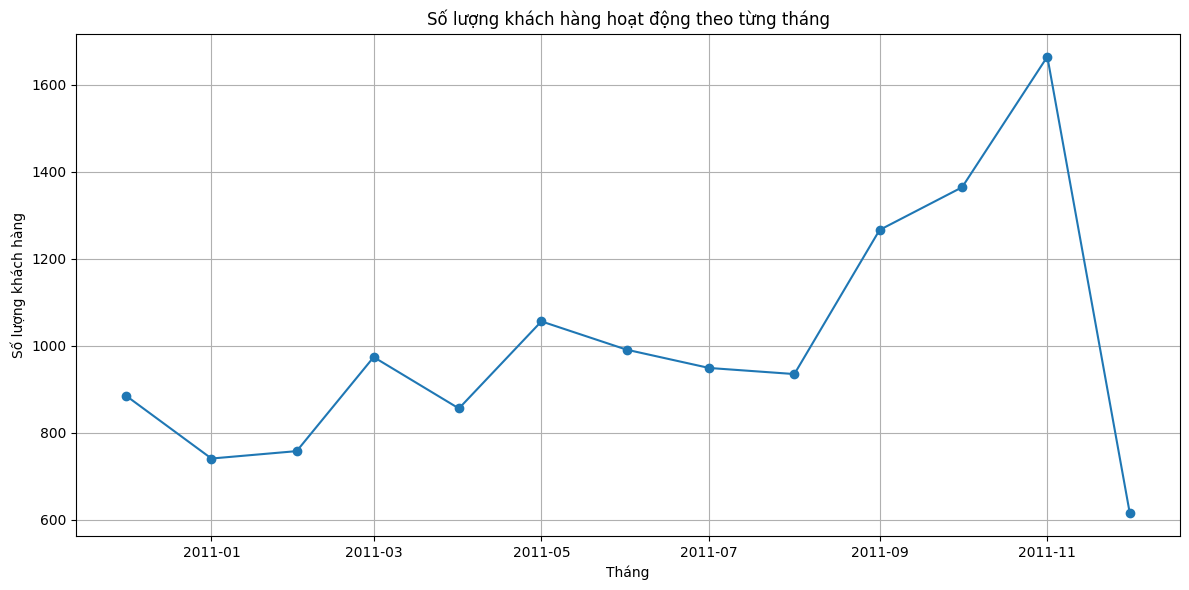

In [14]:
monthly_customers = (
    df_cohort.groupby('InvoiceMonth')['CustomerID']
      .nunique()
      .reset_index()
)

monthly_customers['InvoiceMonth'] = monthly_customers['InvoiceMonth'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_customers['InvoiceMonth'],
    monthly_customers['CustomerID'],
    marker='o'
)

plt.title('Số lượng khách hàng hoạt động theo từng tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng khách hàng')
plt.grid(True)
plt.tight_layout()
plt.show()

## 📈 Nhận xét số lượng khách hàng theo từng tháng

### 1️⃣ Xu hướng mở rộng quy mô khách hàng trong năm 2011
Số lượng khách hàng hoạt động **tăng rõ rệt theo thời gian**, đặc biệt từ cuối năm 2010 sang năm 2011:
- **12/2010:** 885 khách  
- **11/2011:** đạt đỉnh với **1.664 khách**

**Nhận xét:** Quy mô người mua tăng lên cho thấy **doanh nghiệp mở rộng được thị trường và độ phủ khách hàng**, phản ánh nhu cầu chung có xu hướng tăng.

---

### 2️⃣ Mùa cao điểm mua sắm tập trung vào cuối năm
Số lượng khách hàng tăng mạnh trong các tháng:
- **09/2011:** 1.266 khách  
- **10/2011:** 1.364 khách  
- **11/2011:** 1.664 khách  

Sau đó giảm mạnh ở:
- **12/2011:** 615 khách

**Nhận xét:**
- Nhu cầu mua sắm **tăng mạnh vào quý 4**
- **Tháng 11** là thời điểm cao điểm nhất trong năm
- Dữ liệu **12/2011 thấp do chưa đủ cả tháng**, không phản ánh sự suy giảm nhu cầu

---

### 3️⃣ Tăng trưởng không phụ thuộc vào một vài thời điểm riêng lẻ
Mặc dù có một số tháng giảm nhẹ (03 → 04, 05 → 06, 06 → 07), nhưng:
- Mức giảm **ngắn hạn**
- Sau đó **phục hồi nhanh và tiếp tục tăng**

**Nhận xét:** Nhu cầu thị trường **ổn định**, không xuất hiện xu hướng giảm kéo dài.

---

### 4️⃣ Phân bổ nhu cầu đều trong năm, không quá tập trung
Ngoài giai đoạn cao điểm cuối năm:
- Các tháng còn lại vẫn duy trì **lượng khách tương đối cao**
- Không có giai đoạn “đáy” kéo dài

**Nhận xét:** Hoạt động kinh doanh **không phụ thuộc hoàn toàn vào một vài tháng**, giúp giảm rủi ro mùa vụ.

---

### 5️⃣ Đặc điểm nhu cầu mang tính chu kỳ và theo mùa
Sự biến động theo tháng phản ánh:
- Nhu cầu mua phát sinh theo **chu kỳ kinh doanh**
- Mua theo **mùa vụ / dịp trong năm**
- Phù hợp với mô hình **bán buôn hoặc mua không thường xuyên**

## 📈 Khuyến nghị & Hướng hành động

### 1️⃣ Tận dụng mùa cao điểm cuối năm
**Chiến lược:** Tăng cường marketing, khuyến mãi, chiến dịch email / SMS vào **quý 4**, đặc biệt là **tháng 9–11**.  
**Mục tiêu:** Tối đa hóa doanh số và thu hút **khách hàng mới** trong giai đoạn nhu cầu cao.

---

### 2️⃣ Khai thác chu kỳ mua theo mùa
**Chiến lược:** Phân tích **hành vi mua theo mùa hoặc theo chu kỳ kinh doanh**.  
**Hành động:**  
- Thiết kế các **ưu đãi và chương trình bán hàng** phù hợp với từng thời điểm trong năm.  
- Tận dụng **dịp đặc biệt hoặc mùa vụ** để thúc đẩy mua sắm.

---

### 3️⃣ Mở rộng tệp khách hàng mới liên tục
**Chiến lược:** Duy trì hoạt động **acquisition liên tục trong năm**, không chỉ tập trung vào các tháng cao điểm.  
**Hành động:**  
- Quảng cáo và khuyến mãi **đều đặn hàng tháng**.  
- Tối ưu kênh acquisition để thu hút **khách B2B và khách lẻ theo chu kỳ**.

---

### 4️⃣ Giảm rủi ro phụ thuộc mùa vụ
**Chiến lược:** Đảm bảo **dòng khách ổn định ngoài mùa cao điểm**, tránh phụ thuộc quá nhiều vào một vài tháng trong năm.  
**Hành động:**  
- Tổ chức các chương trình **khuyến mãi nhỏ hoặc event theo chu kỳ** giữa năm.  
- Theo dõi **tần suất mua và nhu cầu theo mùa** để dự báo và điều chỉnh kế hoạch kinh doanh.

---

### 5️⃣ Sử dụng dữ liệu để tối ưu chiến lược
**Chiến lược:** Kết hợp dữ liệu **tổng số khách hàng theo tháng** với **phân tích mùa vụ** để hiểu rõ nhu cầu khách hàng.  
**Hành động:**  
- Phân loại khách hàng theo **vùng, loại sản phẩm hoặc nhóm nhu cầu**.  
- Thiết kế **chiến dịch marketing và bán hàng theo nhóm khách** để tối đa hóa hiệu quả.


In [15]:
cohort = df_cohort.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
cohort.columns = ['CustomerID', 'CohortMonth']

df_cohort = df_cohort.merge(cohort, on='CustomerID')

In [16]:
def get_month_diff(d1, d2):
    return (d2.year - d1.year) * 12 + (d2.month - d1.month)

df_cohort['CohortIndex'] = df_cohort.apply(
    lambda x: get_month_diff(x['CohortMonth'], x['InvoiceMonth']) + 1, axis=1)

In [17]:
cohort_data = (
    df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(index='CohortMonth', 
                                columns='CohortIndex',
                                values='CustomerID')

In [18]:
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_size, axis=0)

In [19]:
cohort_data = (
    df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(index='CohortMonth', 
                                columns='CohortIndex', 
                                values='CustomerID')

In [20]:
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


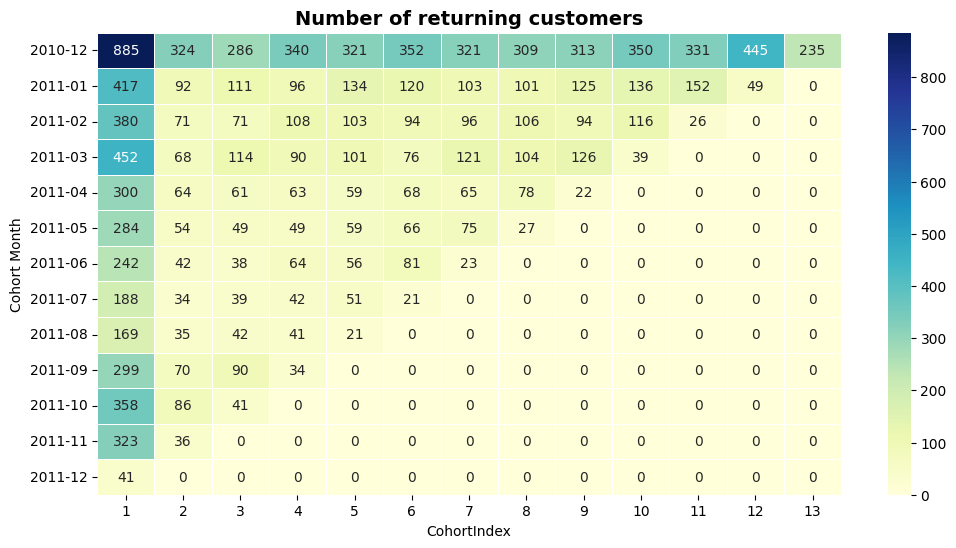

In [21]:
cohort_counts_int = cohort_counts.fillna(0).astype(int)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cohort_counts_int,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt = "d"
)
plt.title("Number of returning customers", fontsize=14, fontweight='bold')
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.show()

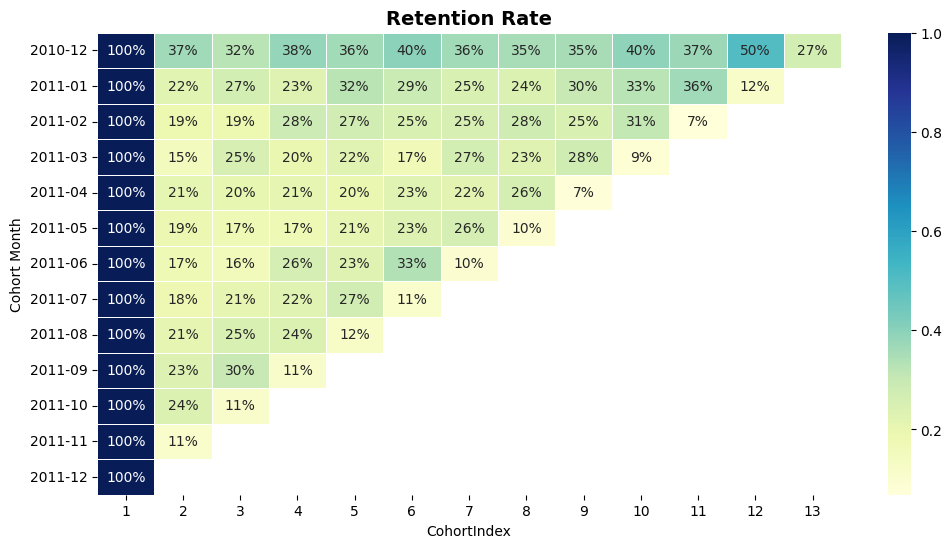

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Retention Rate", fontsize=14, fontweight='bold')
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.show()

## 📊 Phân tích Cohort

### 1️⃣ Quy mô Cohort ban đầu & Yếu tố Mùa vụ
Cohort **12/2010** có quy mô ban đầu lớn nhất (**885 khách hàng**), vượt trội so với các cohort còn lại. Điều này phản ánh rõ ảnh hưởng của **mùa cao điểm cuối năm**, đồng thời cho thấy khả năng tồn tại các **chiến dịch bán hàng hoặc marketing quy mô lớn** trong giai đoạn này.

Các cohort từ **01/2011 đến 06/2011** có quy mô ban đầu tương đối ổn định (khoảng **240–450 khách hàng**), trong khi **cohort 12/2011** có quy mô rất nhỏ (**41 khách hàng**), chủ yếu do **chưa đủ thời gian để quan sát hành vi quay lại**.

**Insight:** Hoạt động **thu hút khách hàng (acquisition)** chịu ảnh hưởng mạnh bởi **yếu tố mùa vụ**, đặc biệt là vào giai đoạn cuối năm.

---

### 2️⃣ Sụt giảm mạnh sau tháng đầu tiên nhưng không mất hoàn toàn
Hầu hết các cohort đều ghi nhận mức sụt giảm đáng kể từ **CohortIndex 1 → 2**, ví dụ:
- **01/2011:** từ 417 → 92 khách  
- **02/2011:** từ 380 → 71 khách  
- **03/2011:** từ 452 → 68 khách  

Tuy nhiên, ở các tháng tiếp theo, số lượng khách hàng có xu hướng **dao động và tăng trở lại theo thời gian**.

**Insight:** Phần lớn khách hàng **không mua liên tục theo từng tháng**, nhưng **có xu hướng quay lại sau một khoảng thời gian gián đoạn**.

---

### 3️⃣ Cohort 12/2010 – Nhóm khách hàng có vòng đời dài
Cohort **12/2010** duy trì số lượng khách hàng hoạt động trong thời gian dài, với nhiều giai đoạn **tăng trở lại rõ rệt**, ví dụ:
- Từ tháng 4 → 6: **286 → 352 khách**
- Từ tháng 11 → 12: **331 → 445 khách**

**Insight:** Đây là cohort có **vòng đời khách hàng dài**, phản ánh:
- Hành vi **mua lặp lại không đều theo tháng**
- Sự tồn tại của nhóm khách **B2B, mua sỉ hoặc mua theo chu kỳ kinh doanh**

---

### 4️⃣ Hành vi mua theo chu kỳ thay vì retention liên tục
Nhiều cohort xuất hiện hiện tượng **gia tăng số khách hàng hoạt động ở các tháng sau**, chẳng hạn:
- **01/2011:** 92 → 111 → 134 → 152 khách  
- **06/2011:** tăng từ 56 → 81 khách ở tháng thứ 6  

**Insight:** Khách hàng có xu hướng **mua theo chu kỳ** thay vì mua đều đặn hàng tháng, bao gồm:
- Mua theo nhu cầu phát sinh
- Mua theo mùa
- Mua định kỳ theo hoạt động kinh doanh

---

## 📈 Khuyến nghị & Chiến lược

### 1️⃣ Tận dụng mùa cao điểm cuối năm
**Chiến lược:**  
- Tăng cường marketing, khuyến mãi, chiến dịch email/SMS vào **quý 4**, đặc biệt từ **tháng 9–11**.  
**Mục tiêu:**  
- Thu hút **khách hàng mới**, tối đa hóa doanh số trong mùa cao điểm.  

---

### 2️⃣ Khai thác hành vi mua theo chu kỳ
**Chiến lược:**  
- Phân nhóm khách hàng theo **chu kỳ mua, mùa vụ hoặc nhu cầu định kỳ**.  
**Hành động:**  
- Thiết kế **ưu đãi và chiến dịch bán hàng** phù hợp với từng nhóm và thời điểm trong năm.  
- Tập trung vào **khách B2B, mua sỉ hoặc mua theo mùa**, giúp khai thác tối đa giá trị khách hàng.

---

### 3️⃣ Mở rộng và duy trì tệp khách hàng mới liên tục
**Chiến lược:**  
- Đẩy mạnh **acquisition liên tục trong năm**, không chỉ tập trung vào các tháng cao điểm.  
**Hành động:**  
- Quảng cáo và khuyến mãi đều đặn theo tháng để duy trì dòng khách ổn định.  
- Tối ưu kênh acquisition cho **khách hàng mới, B2B và khách lẻ theo chu kỳ**.

---

### 4️⃣ Giảm rủi ro phụ thuộc vào mùa vụ
**Chiến lược:**  
- Duy trì **dòng khách ổn định ngoài mùa cao điểm** để giảm rủi ro kinh doanh.  
**Hành động:**  
- Tổ chức các chương trình **khuyến mãi nhỏ hoặc event giữa năm**.  
- Theo dõi **nhu cầu theo mùa** để dự báo và chuẩn bị nguồn lực phù hợp.

---

### 5️⃣ Sử dụng dữ liệu để tối ưu chiến lược
**Chiến lược:**  
- Kết hợp dữ liệu **cohort và tổng số khách theo tháng** để hiểu rõ **chu kỳ và mùa vụ**.  
**Hành động:**  
- Phân tích khách hàng theo **nhóm, sản phẩm, vùng miền** để tối ưu chiến dịch marketing.  
- Thiết kế **ưu đãi, khuyến mãi và chương trình bán hàng** phù hợp với từng nhóm khách hàng và thời điểm.


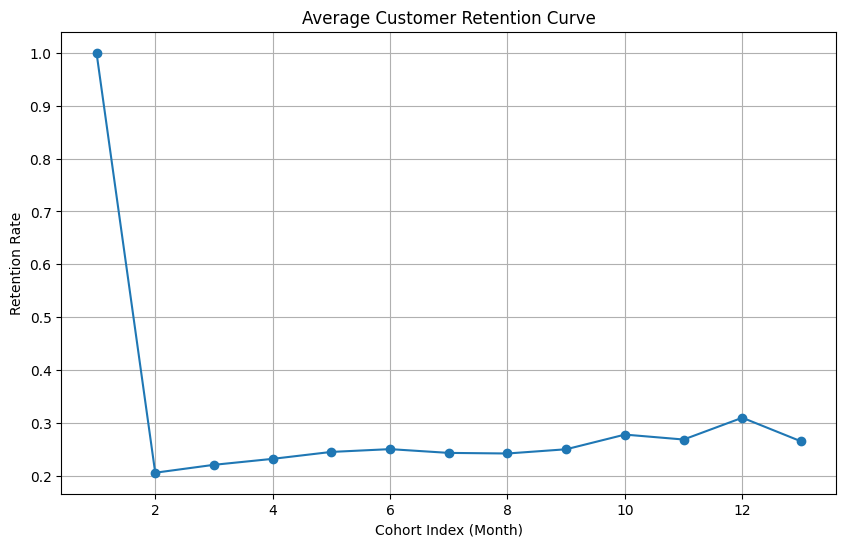

In [23]:
avg_retention = retention.mean()

plt.figure(figsize=(10, 6))

plt.plot(avg_retention.index, avg_retention.values, marker='o')

plt.title("Average Customer Retention Curve")
plt.xlabel("Cohort Index (Month)")
plt.ylabel("Retention Rate")
plt.grid(True)
plt.show()


## 📊 Insight

### 1️⃣ Sụt giảm rất mạnh ở giai đoạn đầu (Tháng 1 → Tháng 2)
Tỷ lệ khách hàng quay lại trung bình giảm đột ngột từ **100% xuống khoảng 20%** ngay sau tháng đầu tiên.

Điều này cho thấy:
- Phần lớn khách hàng **chỉ mua một lần rồi ngưng**
- Tỷ lệ quay lại **ngay tháng kế tiếp rất thấp**

**Insight:**  
👉 **30 ngày đầu sau lần mua đầu tiên** là giai đoạn có **nguy cơ rời bỏ cao nhất** trong toàn bộ vòng đời khách hàng.

---

### 2️⃣ Tỷ lệ quay lại không giảm đều mà tăng dần theo thời gian
Sau tháng thứ 2, tỷ lệ quay lại trung bình **tăng dần theo thời gian**, đạt mức cao nhất vào:
- **Tháng thứ 12: khoảng 31%**

**Insight:**  
👉 Khách hàng **không mất hẳn**, mà có xu hướng **quay lại sau những khoảng thời gian gián đoạn**, thay vì mua đều đặn hàng tháng.

---

### 3️⃣ Hiệu ứng “quay lại muộn”
Tỷ lệ quay lại tăng rõ rệt trong giai đoạn:
- **Tháng thứ 9 → 12: từ khoảng 25% lên 31%**

**Insight:**  
👉 Tồn tại hiện tượng **khách hàng quay lại muộn**, thường sau **9–12 tháng** kể từ lần mua đầu tiên.

**Nguyên nhân hợp lý có thể gồm:**
- Hành vi **mua theo mùa** (đặc biệt vào cuối năm)
- **Chu kỳ mua dài**, phổ biến ở khách hàng doanh nghiệp
- Nhu cầu **lặp lại theo năm**

---

### 4️⃣ Tháng thứ 2 là “điểm sàng lọc” khách hàng
- Tháng thứ 2 chỉ còn khoảng **20% khách hàng quay lại**
- Sau mốc này, tỷ lệ quay lại **ổn định hơn và có xu hướng tăng**

**Insight:**  
👉 Sau tháng đầu tiên, hệ thống **sàng lọc ra nhóm khách hàng chất lượng cao**, có khả năng quay lại tốt hơn và gắn bó dài hạn hơn.

---

### 5️⃣ Tỷ lệ quay lại dài hạn trên 25% là tín hiệu tích cực
Đối với các mô hình **không thu phí định kỳ**:
- Tỷ lệ quay lại dài hạn **20–30%** được xem là **khá tốt**

**Insight kinh doanh:**  
👉 Doanh nghiệp **không hẳn là mất khách**, mà khách hàng **quay lại không đều theo thời gian**, phản ánh hành vi mua theo chu kỳ.

---


## 📈 Khuyến nghị & Hướng hành động

### 1️⃣ Tập trung vào giai đoạn 30 ngày đầu
**Chiến lược:**  
- Nhận diện khách hàng mới ngay sau lần mua đầu tiên để tăng khả năng tương tác.

**Hành động:**  
- Gửi email hoặc SMS chào mừng, giới thiệu sản phẩm liên quan.  
- Cung cấp ưu đãi đặc biệt cho lần mua kế tiếp trong 30 ngày.  

---

### 2️⃣ Khai thác hành vi mua theo chu kỳ và mùa vụ
**Chiến lược:**  
- Phân nhóm khách hàng dựa trên chu kỳ mua, mùa vụ và nhu cầu định kỳ.

**Hành động:**  
- Lên kế hoạch khuyến mãi, ưu đãi hoặc nhắc mua vào những thời điểm khách thường quay lại.  
- Áp dụng lifecycle marketing theo từng nhóm khách hàng và chu kỳ nhu cầu.  

---

### 3️⃣ Tận dụng khách hàng “quay lại muộn”
**Chiến lược:**  
- Nhận diện nhóm khách có tiềm năng quay lại muộn để tăng giá trị khách hàng (CLV).

**Hành động:**  
- Gửi thông báo, ưu đãi đặc biệt vào cuối năm hoặc theo chu kỳ lịch sử.  
- Thiết kế các chiến dịch khuyến mãi theo mùa nhắm vào nhóm khách B2B hoặc mua sỉ.  

---

### 4️⃣ Giám sát & phân tích dữ liệu khách hàng
**Chiến lược:**  
- Kết hợp dữ liệu cohort và tổng số khách hàng theo tháng để tối ưu chiến lược marketing và bán hàng.

**Hành động:**  
- Theo dõi khách mua theo chu kỳ, phân tích hành vi và nhu cầu.  
- Điều chỉnh kênh marketing, ưu đãi và chiến dịch dựa trên nhóm khách hàng và mùa vụ.  

---

### 5️⃣ Tối ưu hóa tăng trưởng không phụ thuộc vào retention đều hàng tháng
**Chiến lược:**  
- Nhận thức rằng khách hàng không mua đều, nhưng tổng số khách hàng theo tháng vẫn tăng.

**Hành động:**  
- Đảm bảo acquisition liên tục để mở rộng tệp khách hàng mới.  
- Duy trì hoạt động marketing ổn định quanh năm, không chỉ tập trung vào các tháng cao điểm.

In [24]:
#end